# Prediction-Driven Trade Router

This notebook takes the prediction-ready execution dataset, merges an external forecast file from a teammate, and ranks which venue gives the best executable price for the model's direction. It stays usable even before the model exists: if no prediction file is present, it exports the template and shows the routing context only.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from prediction_execution import (
    DEFAULT_HORIZONS_HOURS,
    build_trade_candidates,
    export_prediction_ready_bundle,
    market_paths,
    merge_external_predictions,
    prepare_prediction_ready_bundle,
)

plt.style.use('default')

MARKET_SLUG = 'optimism_wbtc_weth'
HORIZONS_HOURS = DEFAULT_HORIZONS_HOURS
MIN_EXPECTED_EDGE_BPS = 5.0

paths = market_paths(PROJECT_ROOT, MARKET_SLUG)
bundle = prepare_prediction_ready_bundle(PROJECT_ROOT, MARKET_SLUG, horizons_hours=HORIZONS_HOURS)
exported_paths = export_prediction_ready_bundle(bundle, horizons_hours=HORIZONS_HOURS)

PREDICTION_FILE = paths['output_dir'] / 'external_predictions.csv'
prediction_frame, prediction_info = merge_external_predictions(bundle['model_frame'], PREDICTION_FILE)
trade_candidates = build_trade_candidates(prediction_frame, min_expected_edge_bps=MIN_EXPECTED_EDGE_BPS)
trade_candidates.to_csv(paths['trade_candidates'], index=False)

actionable = trade_candidates[trade_candidates['trade_side'] != 'hold'].copy()
summary_rows = [
    {'field': 'market_slug', 'value': MARKET_SLUG},
    {'field': 'prediction_status', 'value': prediction_info['status']},
    {'field': 'prediction_file', 'value': str(PREDICTION_FILE)},
    {'field': 'template_file', 'value': str(exported_paths['prediction_template'])},
    {'field': 'prediction_coverage', 'value': prediction_info.get('coverage', np.nan)},
    {'field': 'actionable_rows', 'value': int(len(actionable))},
    {'field': 'min_expected_edge_bps', 'value': MIN_EXPECTED_EDGE_BPS},
]

display(pd.DataFrame(summary_rows))
if prediction_info['status'] == 'missing':
    display(Markdown('## Next Step'))
    display(Markdown(
        'No external prediction file was found yet. Fill the exported `predictions_input_template.csv`, '
        'save it as `external_predictions.csv` in the same output folder, then rerun this notebook.'
    ))
else:
    display(Markdown('## Loaded Prediction Columns'))
    display(pd.DataFrame({'prediction_column': prediction_info.get('prediction_columns', [])}))

,field,value
0,market_slug,optimism_wbtc_weth
1,prediction_status,missing
2,prediction_file,/Users/bilguuntsolmon/Desktop/main/uni/finance...
3,template_file,/Users/bilguuntsolmon/Desktop/main/uni/finance...
4,prediction_coverage,NaN
5,actionable_rows,0
6,min_expected_edge_bps,5.0


## Next Step

No external prediction file was found yet. Fill the exported `predictions_input_template.csv`, save it as `external_predictions.csv` in the same output folder, then rerun this notebook.

In [2]:
display(Markdown('## Trade Candidate Table'))
candidate_columns = [
    'timestamp', 'trade_side', 'execution_venue', 'execution_price_usd', 'predicted_fair_value',
    'expected_buy_edge_bps', 'expected_sell_edge_bps', 'expected_edge_bps',
    'best_buy_venue', 'best_sell_venue', 'cross_exchange_dispersion_bps'
]
display(trade_candidates.loc[:, [c for c in candidate_columns if c in trade_candidates.columns]].head(50))

display(Markdown('## Actionable Trades Only'))
display(actionable.loc[:, [c for c in candidate_columns if c in actionable.columns]].head(50))

display(Markdown('## Prediction Template Preview'))
display(bundle['prediction_template'].head(25))

## Trade Candidate Table

,timestamp,trade_side,execution_venue,execution_price_usd,predicted_fair_value,expected_buy_edge_bps,expected_sell_edge_bps,expected_edge_bps,best_buy_venue,best_sell_venue,cross_exchange_dispersion_bps
0,2026-03-16 08:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,velodrome-finance-slipstream | WETH / WBTC 0.05%,uniswap_v3_optimism | WETH / WBTC 0.3%,41.154307
1,2026-03-16 09:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,21.905174
2,2026-03-16 10:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,uniswap_v3_optimism | WETH / WBTC 0.3%,velodrome-finance-slipstream | WETH / WBTC 0.05%,67.773053
3,2026-03-16 11:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,uniswap_v3_optimism | WETH / WBTC 0.3%,velodrome-finance-slipstream | WETH / WBTC 0.05%,49.953763
4,2026-03-16 12:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,2.640838
5,2026-03-16 13:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,velodrome-finance-slipstream | WETH / WBTC 0.05%,uniswap_v3_optimism | WETH / WBTC 0.3%,33.944019
6,2026-03-16 14:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,sushiswap-v3-optimism | WETH / WBTC 0.3%,velodrome-finance-slipstream | WETH / WBTC 0.05%,37.579635
7,2026-03-16 15:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,9.470994
8,2026-03-16 16:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,7.079719
9,2026-03-16 17:00:00+00:00,hold,None,NaN,NaN,NaN,NaN,NaN,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,6.811540


## Actionable Trades Only

,timestamp,trade_side,execution_venue,execution_price_usd,predicted_fair_value,expected_buy_edge_bps,expected_sell_edge_bps,expected_edge_bps,best_buy_venue,best_sell_venue,cross_exchange_dispersion_bps


## Prediction Template Preview

,timestamp,market_slug,reference_price_usd,predicted_return_1h_bps,predicted_price_1h,predicted_return_4h_bps,predicted_price_4h,predicted_return_24h_bps,predicted_price_24h,prediction_source,prediction_notes
0,2026-03-16 08:00:00+00:00,optimism_wbtc_weth,73040.433159,NaN,NaN,NaN,NaN,NaN,NaN,,
1,2026-03-16 09:00:00+00:00,optimism_wbtc_weth,72946.410259,NaN,NaN,NaN,NaN,NaN,NaN,,
2,2026-03-16 10:00:00+00:00,optimism_wbtc_weth,73143.226625,NaN,NaN,NaN,NaN,NaN,NaN,,
3,2026-03-16 11:00:00+00:00,optimism_wbtc_weth,73143.226625,NaN,NaN,NaN,NaN,NaN,NaN,,
4,2026-03-16 12:00:00+00:00,optimism_wbtc_weth,73615.972399,NaN,NaN,NaN,NaN,NaN,NaN,,
5,2026-03-16 13:00:00+00:00,optimism_wbtc_weth,74020.340399,NaN,NaN,NaN,NaN,NaN,NaN,,
6,2026-03-16 14:00:00+00:00,optimism_wbtc_weth,73222.198186,NaN,NaN,NaN,NaN,NaN,NaN,,
7,2026-03-16 15:00:00+00:00,optimism_wbtc_weth,73214.197578,NaN,NaN,NaN,NaN,NaN,NaN,,
8,2026-03-16 16:00:00+00:00,optimism_wbtc_weth,73583.447805,NaN,NaN,NaN,NaN,NaN,NaN,,
9,2026-03-16 17:00:00+00:00,optimism_wbtc_weth,73697.630365,NaN,NaN,NaN,NaN,NaN,NaN,,


## Routing Dashboard

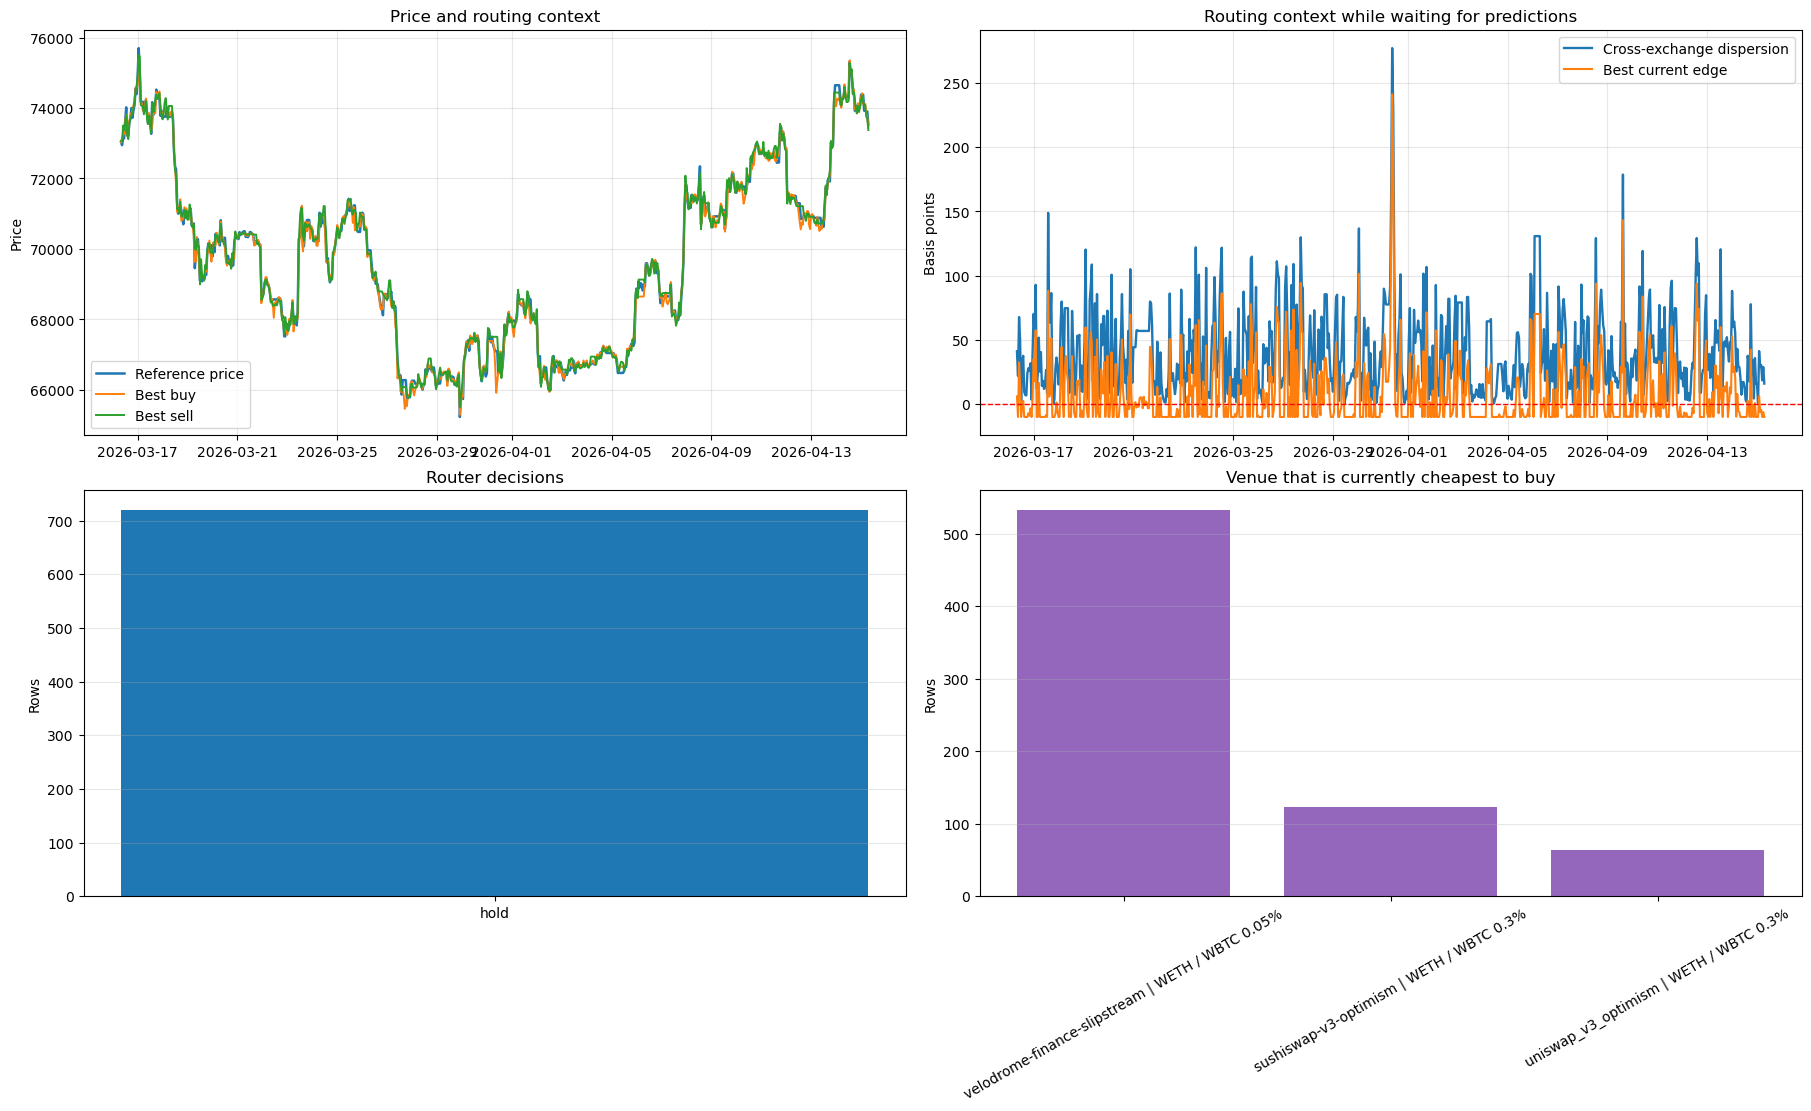

In [3]:
display(Markdown('## Routing Dashboard'))

router = prediction_frame.copy().sort_values('timestamp').reset_index(drop=True)
has_predictions = router['predicted_fair_value'].notna().any()
action_counts = trade_candidates['trade_side'].value_counts().rename_axis('trade_side').reset_index(name='rows')
if actionable.empty:
    venue_counts = router['best_buy_venue'].value_counts().rename_axis('venue').reset_index(name='rows')
else:
    venue_counts = actionable['execution_venue'].value_counts().rename_axis('venue').reset_index(name='rows')

fig, axes = plt.subplots(2, 2, figsize=(18, 11), constrained_layout=True)

axes[0, 0].plot(router['timestamp'], router['reference_price_usd'], linewidth=1.8, label='Reference price')
axes[0, 0].plot(router['timestamp'], router['best_buy_effective_price_usd'], linewidth=1.4, label='Best buy')
axes[0, 0].plot(router['timestamp'], router['best_sell_effective_price_usd'], linewidth=1.4, label='Best sell')
if has_predictions:
    axes[0, 0].plot(router['timestamp'], router['predicted_fair_value'], linewidth=1.6, label='Predicted fair value')
axes[0, 0].set_title('Price and routing context')
axes[0, 0].set_ylabel('Price')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

if has_predictions:
    axes[0, 1].plot(router['timestamp'], router['expected_buy_edge_bps'], linewidth=1.6, label='Expected buy edge')
    axes[0, 1].plot(router['timestamp'], router['expected_sell_edge_bps'], linewidth=1.6, label='Expected sell edge')
    axes[0, 1].axhline(MIN_EXPECTED_EDGE_BPS, color='tab:green', linestyle='--', linewidth=1, label='Trade threshold')
    axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
    axes[0, 1].set_title('Expected edge from predictions')
    axes[0, 1].set_ylabel('Basis points')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()
else:
    axes[0, 1].plot(router['timestamp'], router['cross_exchange_dispersion_bps'], linewidth=1.7, label='Cross-exchange dispersion')
    axes[0, 1].plot(router['timestamp'], router['best_cross_exchange_edge_bps'], linewidth=1.5, label='Best current edge')
    axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
    axes[0, 1].set_title('Routing context while waiting for predictions')
    axes[0, 1].set_ylabel('Basis points')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()

axes[1, 0].bar(action_counts['trade_side'], action_counts['rows'], color=['tab:blue', 'tab:orange', 'tab:green'][:len(action_counts)])
axes[1, 0].set_title('Router decisions')
axes[1, 0].set_ylabel('Rows')
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].bar(venue_counts['venue'], venue_counts['rows'], color='tab:purple')
axes[1, 1].set_title('Chosen execution venue' if not actionable.empty else 'Venue that is currently cheapest to buy')
axes[1, 1].set_ylabel('Rows')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.show()

In [4]:
display(Markdown('## Output Files'))
output_rows = [
    {'artifact': 'prediction_template', 'path': str(exported_paths['prediction_template'])},
    {'artifact': 'model_frame', 'path': str(exported_paths['model_frame'])},
    {'artifact': 'trade_candidates', 'path': str(paths['trade_candidates'])},
]
display(pd.DataFrame(output_rows))

## Output Files

,artifact,path
0,prediction_template,/Users/bilguuntsolmon/Desktop/main/uni/finance...
1,model_frame,/Users/bilguuntsolmon/Desktop/main/uni/finance...
2,trade_candidates,/Users/bilguuntsolmon/Desktop/main/uni/finance...
